# Data Preprocessing and Exploration Overview

This notebook provides a comprehensive overview of the materials recycling dataset, detailing each column's purpose, usage, importance level, and relevant notes for preprocessing and modeling.

| Column                           | Description                         | Usage            | Importance | Notes            |
| -------------------------------- | ----------------------------------- | ---------------- | ---------- | ---------------- |
| record_id                        | Unique record identifier            | Tracking         | Low        | Drop in modeling |
| material_code                    | Internal material code              | None             | Low        | Drop             |
| material_name                    | Name of item (bottle, can, etc.)    | NLP, Input       | High 🔥    | مهم جدًا         |
| material_type                    | General type (plastic, metal, etc.) | Feature / Target | High 🔥    |                  |
| material_subtype                 | Specific type (PET, HDPE)           | Feature          | High 🔥    |                  |
| recyclable                       | Recyclable or not (0/1)             | Target           | High 🔥    |                  |
| recyclability_category           | High/Medium/Low recyclability       | Classification   | Medium     |                  |
| quantity_kg                      | Quantity in kg                      | Analysis         | Low        |                  |
| density_kg_per_m3                | Material density                    | Feature          | Medium     |                  |
| condition                        | Clean / Dirty                       | Feature          | High 🔥    | مؤثر جدًا        |
| moisture_content_pct             | Moisture percentage                 | Feature          | Medium     |                  |
| contamination_level              | Level of contamination              | Feature          | High 🔥    | فيه missing      |
| contamination_type               | Type of contamination               | Feature          | Medium     |                  |
| size_category                    | Size (small/medium/large)           | Feature          | Medium     |                  |
| country                          | Country                             | Analysis         | Medium     | Model بحذر       |
| region                           | Region                              | Analysis         | Medium     |                  |
| income_level                     | Economic level                      | Analysis         | Low        |                  |
| urban_type                       | Urban/Rural                         | Analysis         | Medium     |                  |
| collection_method                | Collection method                   | Feature          | High       |                  |
| season                           | Season                              | Analysis         | Low        |                  |
| month                            | Month                               | Analysis         | Low        |                  |
| year                             | Year                                | Analysis         | Low        |                  |
| co2_saved_total_kg               | CO2 saved                           | Analysis         | High       | ❌ Leakage        |
| co2_landfill_total_kg            | CO2 if landfill                     | Analysis         | High       | ❌                |
| ghg_reduction_kg_co2e            | GHG reduction                       | Analysis         | High       | ❌                |
| net_climate_benefit_kg_co2e      | Net benefit                         | Analysis         | High       | ❌                |
| global_recycling_rate_pct        | Global recycling rate               | Analysis         | Medium     |                  |
| country_recycling_rate_pct       | Country recycling rate              | Analysis         | Medium     |                  |
| local_infrastructure_score_0to10 | Infrastructure quality              | Feature          | High 🔥    |                  |
| recycling_facility_distance_km   | Distance to facility                | Feature          | High 🔥    |                  |
| collection_coverage_pct          | Collection coverage                 | Feature          | Medium     |                  |
| informal_sector_involved         | Informal sector (0/1)               | Feature          | Medium     |                  |
| actual_disposal_method           | Actual disposal method              | Target           | High 🔥    |                  |
| counterfactual_disposal          | Alternative disposal                | Analysis         | Medium     |                  |
| market_price_usd_per_kg          | Market price                        | Feature          | High       |                  |
| processing_cost_usd_per_kg       | Processing cost                     | Feature          | High       |                  |
| transport_cost_usd_per_kg        | Transport cost                      | Feature          | High       |                  |
| collection_cost_usd_per_kg       | Collection cost                     | Feature          | High       |                  |
| total_net_revenue_usd            | Total revenue                       | Analysis         | High       | ❌ Leakage        |
| water_saved_total_liters         | Water saved                         | Analysis         | Medium     | ❌                |
| energy_saved_total_mj            | Energy saved                        | Analysis         | Medium     | ❌                |
| landfill_space_saved_m3          | Landfill space saved                | Analysis         | Medium     | ❌                |
| hazardous                        | Hazardous (0/1)                     | Feature          | High 🔥    |                  |
| requires_sorting                 | Needs sorting                       | Feature          | High       |                  |
| requires_cleaning                | Needs cleaning                      | Feature          | High       |                  |
| requires_special_facility        | Needs special facility              | Feature          | High       |                  |
| is_single_material               | Single material                     | Feature          | Medium     |                  |
| can_be_reused_as_is              | Reusable directly                   | Feature          | High 🔥    |                  |
| reuse_potential_1to5             | Reuse score (1–5)                   | Recommendation   | High 🔥    |                  |
| recyclability_score_0to100       | Recyclability score                 | Analysis         | High       | ❌                |
| eco_impact_score_0to100          | Environmental score                 | Analysis         | High       | ❌                |
| economic_value_score_0to100      | Economic score                      | Analysis         | High       | ❌                |
| composite_sustainability_score   | Overall score                       | Analysis         | High       | ❌                |
| data_source                      | Source of data                      | Tracking         | Low        | Drop             |

### Notes:
- Columns marked ❌ are excluded from modeling due to data leakage.
- High 🔥 columns are considered critical features.
- Some columns are used only for analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import folium


In [2]:
df =  pd.read_csv(r"C:\Users\USERR\Desktop\depi project\materials_recycling_core.csv")
df

,record_id,material_code,material_name,material_subtype,material_type,recyclable,recyclability_category,quantity_kg,batch_size_category,density_kg_per_m3,...,is_single_material,can_be_reused_as_is,reuse_potential_1to5,melt_or_process_temp_c,annual_global_waste_million_tonnes,recyclability_score_0to100,eco_impact_score_0to100,economic_value_score_0to100,composite_sustainability_score,data_source
0,rec_000001,OCC,Corrugated Cardboard (OCC),Corrugated Cardboard (OCC),Paper,1,Highly Recyclable,5425.21,Single Item,100,...,1,0,4,233,118.0,100.0,100.0,100.0,100.00,EPA WARM v15 2023 | World Bank What-a-Waste 2....
1,rec_000002,MW,Mixed Waste Paper,Mixed Waste Paper,Paper,1,Highly Recyclable,0.98,Small Batch,100,...,1,0,2,233,70.0,100.0,100.0,4.3,80.86,EPA WARM v15 2023 | World Bank What-a-Waste 2....
2,rec_000003,LED,LED Bulb,LED Bulb,Electronic,1,Low Recyclability,52.46,Medium Batch,200,...,0,0,2,0,0.5,65.5,43.5,22.9,47.08,EPA WARM v15 2023 | World Bank What-a-Waste 2....
3,rec_000004,Denim,Denim / Heavy Cotton,Denim / Heavy Cotton,Textile,1,Low Recyclability,1.07,Medium Batch,1540,...,1,0,5,0,8.0,69.0,55.5,9.7,51.06,EPA WARM v15 2023 | World Bank What-a-Waste 2....
4,rec_000005,Asphalt,Asphalt / Bitumen Scrap,Asphalt / Bitumen Scrap,Construction,1,Highly Recyclable,1.60,Small Batch,2300,...,1,0,2,160,600.0,100.0,25.2,0.8,46.50,EPA WARM v15 2023 | World Bank What-a-Waste 2....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,rec_024996,Ceramic,Broken Ceramic / Tile / Sanitary,Broken Ceramic / Tile / Sanitary,Ceramic,0,Non-Recyclable,7.62,Small Batch,2300,...,1,0,3,1600,8.0,41.1,0.0,0.4,14.46,EPA WARM v15 2023 | World Bank What-a-Waste 2....
24996,rec_024997,CFL,CFL / Fluorescent Lamp,CFL / Fluorescent Lamp,Electronic,1,Low Recyclability,0.50,Single Item,200,...,0,0,1,0,0.8,66.4,47.1,20.1,48.46,EPA WARM v15 2023 | World Bank What-a-Waste 2....
24997,rec_024998,Glass_Green,Green Glass Bottle,Green Glass Bottle,Glass,1,Recyclable,2.13,Single Item,2500,...,1,0,4,1500,12.0,92.6,19.9,4.1,42.18,EPA WARM v15 2023 | World Bank What-a-Waste 2....
24998,rec_024999,Leather,Leather Goods,Leather Goods,Textile,0,Non-Recyclable,31.69,Small Batch,860,...,1,0,3,0,2.0,42.4,0.0,1.6,15.16,EPA WARM v15 2023 | World Bank What-a-Waste 2....


In [84]:
df.info(max_cols=100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   record_id                           25000 non-null  object 
 1   material_code                       25000 non-null  object 
 2   material_name                       25000 non-null  object 
 3   material_subtype                    25000 non-null  object 
 4   material_type                       25000 non-null  object 
 5   recyclable                          25000 non-null  int64  
 6   recyclability_category              25000 non-null  object 
 7   quantity_kg                         25000 non-null  float64
 8   batch_size_category                 25000 non-null  object 
 9   density_kg_per_m3                   25000 non-null  int64  
 10  condition                           25000 non-null  object 
 11  moisture_content_pct                25000

In [85]:
df.describe()

,recyclable,quantity_kg,density_kg_per_m3,moisture_content_pct,month,year,co2_saved_kg_per_kg,co2_saved_total_kg,co2_landfill_kg_per_kg,co2_landfill_total_kg,...,requires_special_facility,is_single_material,can_be_reused_as_is,reuse_potential_1to5,melt_or_process_temp_c,annual_global_waste_million_tonnes,recyclability_score_0to100,eco_impact_score_0to100,economic_value_score_0to100,composite_sustainability_score
count,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,0.852480,870.298047,2409.26916,13.248800,6.488760,2021.504600,12.726230,1.078095e+04,0.279110,239.513245,...,0.336680,0.752080,0.045120,2.748360,393.33308,66.693016,70.572848,50.933256,42.522492,56.124494
std,0.354631,1883.768645,2645.15884,8.654592,3.442736,1.713691,34.741520,7.354851e+04,0.376532,926.191601,...,0.472584,0.431814,0.207571,1.085967,555.31834,175.284691,23.614676,34.849238,42.731659,24.301989
min,0.000000,0.100000,100.00000,0.000000,1.000000,2019.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.00000,0.200000,11.600000,0.000000,0.000000,4.130000
25%,1.000000,1.880000,920.00000,6.400000,3.000000,2020.000000,0.259300,7.280000e-01,0.009300,0.004000,...,0.000000,1.000000,0.000000,2.000000,0.00000,3.200000,53.800000,20.675000,4.800000,40.910000
50%,1.000000,33.410000,1380.00000,12.800000,6.000000,2022.000000,2.023300,3.196900e+01,0.126850,0.924000,...,0.000000,1.000000,0.000000,3.000000,165.00000,9.000000,69.700000,49.800000,18.000000,54.230000
75%,1.000000,575.150000,2500.00000,19.300000,9.000000,2023.000000,4.246775,9.004110e+02,0.406100,37.982500,...,1.000000,1.000000,0.000000,3.000000,420.00000,42.000000,95.800000,82.200000,100.000000,81.180000
max,1.000000,9999.160000,11340.00000,59.900000,12.000000,2024.000000,215.888800,2.004012e+06,2.089400,18730.306000,...,1.000000,1.000000,1.000000,5.000000,1600.00000,931.000000,100.000000,100.000000,100.000000,100.000000


In [86]:
df.describe(include=['object'])

,record_id,material_code,material_name,material_subtype,material_type,recyclability_category,batch_size_category,condition,contamination_level,contamination_type,size_category,country,region,income_level,urban_type,collection_method,season,actual_disposal_method,counterfactual_disposal,data_source
count,25000,25000,25000,25000,25000,25000,25000,25000,14988,14988,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,25000,68,68,68,12,4,6,10,3,9,5,20,6,3,7,12,4,9,1,1
top,rec_025000,Steel_Tin,Tin-Plated Steel Cans,Tin-Plated Steel Cans,Electronic,Low Recyclability,Small Batch,Clean,Low,Biological,Industrial (100-1000kg),Egypt,Asia-Pacific,High,Suburban,Door-to-door,Autumn,Recycled,Landfill,EPA WARM v15 2023 | World Bank What-a-Waste 2....
freq,1,410,410,410,4780,8006,4225,2560,7505,1721,5146,1325,7514,13814,3691,2173,6279,10503,25000,25000


In [87]:
df['contamination_level'].value_counts()

contamination_level
Low       7505
Medium    5073
High      2410
Name: count, dtype: int64

In [88]:
df['contamination_score'] = (
    df['requires_cleaning'] * 2 +
    df['hazardous'] * 3 +
    (df['moisture_content_pct'] / 50) +
    df['condition'].map({'clean':0, 'dirty':2})
)

In [89]:
def to_level(x):
    if x <= 1.5:
        return 'Low'
    elif x <= 3:
        return 'Medium'
    else:
        return 'High'

df['contamination_level_filled'] = df['contamination_score'].apply(to_level)

In [90]:
df['contamination_level'] = df['contamination_level'].fillna(df['contamination_level_filled'],)

In [91]:
df['material_type'].value_counts()

material_type
Electronic      4780
Plastic         3729
Metal           3719
Textile         2208
Paper           2193
Glass           1872
Construction    1419
Composite       1418
Rubber          1106
Organic         1098
Wood            1059
Ceramic          399
Name: count, dtype: int64

In [92]:
df['contamination_type'].value_counts()

contamination_type
Biological         1721
Food residue       1701
Chemical           1685
Mixed waste        1683
Moisture           1664
Adhesive           1658
Paint              1655
Oil                1618
Metal fasteners    1603
Name: count, dtype: int64

In [93]:
df['material_name'].value_counts()

material_name
Tin-Plated Steel Cans               410
Clear Glass Bottle / Jar            403
Nylon / Polyamide                   403
Copper Mixed Scrap                  402
Broken Ceramic / Tile / Sanitary    399
                                   ... 
Wooden Pallet / Offcut              342
Used Cooking Oil / Grease           341
Smartphone / Feature Phone          339
Brick / Block Rubble                334
Denim / Heavy Cotton                333
Name: count, Length: 68, dtype: int64

In [ ]:
def infer_contamination_type(row):
    
    mt = row['material_type']
    
    #  Hazardous → Chemical
    if row['hazardous'] == 1:
        return 'Chemical'
    
    #  Organic materials
    if mt == 'Organic':
        if row['moisture_content_pct'] > 40:
            return 'Moisture'
        else:
            return 'Biological'
    
    # Plastic materials
    if mt == 'Plastic':
        if row['requires_cleaning'] == 1:
            return 'Adhesive'
        elif row['condition'] == 'dirty':
            return 'Mixed waste'
        else:
            return 'Food residue'
    
    #  Metal materials
    if mt == 'Metal':
        if row['condition'] == 'dirty':
            return 'Oil'
        elif row['requires_special_facility'] == 1:
            return 'Metal fasteners'
        else:
            return 'Mixed waste'
    
    #  Paper / Textile
    if mt in ['Paper', 'Textile']:
        if row['condition'] == 'dirty':
            return 'Food residue'
        else:
            return 'Adhesive'
    
    #  Glass / Ceramic
    if mt in ['Glass', 'Ceramic']:
        if row['requires_cleaning'] == 1:
            return 'Chemical'
        else:
            return 'Mixed waste'
    
    #  Default fallback
    return 'Mixed waste'


df['contamination_type'] = df['contamination_type'].fillna(
    df.apply(infer_contamination_type, axis=1)
)

In [95]:
df['contamination_type'].value_counts()

contamination_type
Chemical           5117
Adhesive           4786
Mixed waste        4690
Biological         2029
Moisture           1801
Food residue       1701
Paint              1655
Oil                1618
Metal fasteners    1603
Name: count, dtype: int64

In [96]:
df.info(max_cols=100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 74 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   record_id                           25000 non-null  object 
 1   material_code                       25000 non-null  object 
 2   material_name                       25000 non-null  object 
 3   material_subtype                    25000 non-null  object 
 4   material_type                       25000 non-null  object 
 5   recyclable                          25000 non-null  int64  
 6   recyclability_category              25000 non-null  object 
 7   quantity_kg                         25000 non-null  float64
 8   batch_size_category                 25000 non-null  object 
 9   density_kg_per_m3                   25000 non-null  int64  
 10  condition                           25000 non-null  object 
 11  moisture_content_pct                25000

In [97]:
df.drop(columns=['material_subtype'],inplace=True)

# Data analysis and visulaz 

In [3]:
analysis_cols = [

    # Material info
    'material_name', 'material_type', 'size_category',

    # Recycling
    'recyclable', 'recyclability_category', 'reuse_potential_1to5', 'can_be_reused_as_is',

    # Contamination
    'contamination_level', 'contamination_type',
    'moisture_content_pct', 'condition',

    # Context
    'country', 'region', 'urban_type', 'income_level', 'season',

    # Environmental
    'co2_saved_total_kg', 'co2_landfill_total_kg',
    'ghg_reduction_kg_co2e', 'water_saved_total_liters',
    'energy_saved_total_mj', 'landfill_space_saved_m3',

    # Economic
    'market_price_usd_per_kg', 'processing_cost_usd_per_kg',
    'transport_cost_usd_per_kg', 'collection_cost_usd_per_kg',
    'total_net_revenue_usd', 'economic_value_score_0to100',

    # System
    'collection_method', 'recycling_facility_distance_km',
    'local_infrastructure_score_0to10',
    'collection_coverage_pct', 'informal_sector_involved',

    # Risk
    'hazardous', 'requires_sorting',
    'requires_cleaning', 'requires_special_facility',

    # Scores
    'recyclability_score_0to100',
    'eco_impact_score_0to100',
    'composite_sustainability_score'
]

df_analysis = df[analysis_cols].copy()

In [99]:
df_analysis['material_name'].sample(20)


16124                          Zinc Scrap
5625                 Denim / Heavy Cotton
15708           PET Plastic Bottle / Film
23298                Sawdust / Wood Chips
7372                   Passenger Car Tyre
15101                       Old Magazines
21060                  Brown Glass Bottle
6830                  Lithium-Ion Battery
21744                    CRT Monitor / TV
12162                   Mixed Waste Paper
8789     Broken Ceramic / Tile / Sanitary
1145                             LED Bulb
14914           Concrete / Masonry Rubble
12731          Tetra Pak / Aseptic Carton
5065                         NiMH Battery
13285              Refrigerator / AC Unit
13829               Printed Circuit Board
9324                   White Office Paper
20641            Cotton Clothing / Fabric
24864            Mixed / Blended Textiles
Name: material_name, dtype: object

In [123]:
df['co2_saved_total_kg'].groupby(df['material_type']).sample(20)

10125    0.000
4429     0.000
17047    0.000
5358     0.000
21810    0.000
         ...  
19059    0.124
7932     0.000
5956     0.439
20711    0.920
15987    1.725
Name: co2_saved_total_kg, Length: 240, dtype: float64

## Environmental Impact & CO2

Which materials achieve the highest level of greenhouse gas reduction but also economic benefit?

In [ ]:
grouped = df_analysis.groupby('material_type').agg({
    'ghg_reduction_kg_co2e': 'mean',
    'total_net_revenue_usd': 'mean'
}).reset_index()

grouped

,material_type,ghg_reduction_kg_co2e,total_net_revenue_usd
0,Ceramic,0.000000,0.000000
1,Composite,963.976296,192.180176
2,Construction,66.468398,21.444764
3,Electronic,48406.658344,6714.166136
4,Glass,173.144458,71.810160
5,Metal,4228.659239,4117.371361
6,Organic,992.885009,81.664599
7,Paper,2124.223002,145.580406
8,Plastic,1419.671504,91.016798
9,Rubber,889.531810,81.847803


In [142]:
top = grouped.sort_values(
    by='ghg_reduction_kg_co2e',
    ascending=False
).head(10)

In [137]:


fig = px.bar(
    top,
    x='material_type',
    y='ghg_reduction_kg_co2e',
    color='total_net_revenue_usd',
    title='Top Materials: Impact vs Profit'
)

fig.show()

CO2 Landfill Total by Country

In [6]:
df_analysis['country'].value_counts()

country
Egypt           1325
Turkey          1317
South Korea     1296
Australia       1291
Canada          1281
Netherlands     1275
Japan           1263
Saudi Arabia    1260
France          1259
Jordan          1252
USA             1243
Morocco         1241
UK              1236
China           1225
India           1225
Nigeria         1223
UAE             1222
Indonesia       1214
Germany         1188
Brazil          1164
Name: count, dtype: int64

In [20]:
geo_df = df_analysis.groupby(['country', 'material_type']).agg({
    'co2_landfill_total_kg': 'sum',
}).reset_index()

In [22]:
fig = px.bar(
    geo_df,
    x='country',
    y='co2_landfill_total_kg',
    title='CO2 Landfill Total by Country',
    color= 'material_type'
    
)

fig.show()

In [26]:
df_analysis[['co2_saved_total_kg','co2_landfill_total_kg']].describe()

,co2_saved_total_kg,co2_landfill_total_kg
count,2.500000e+04,25000.000000
mean,1.078095e+04,239.513245
std,7.354851e+04,926.191601
min,0.000000e+00,0.000000
25%,7.280000e-01,0.004000
50%,3.196900e+01,0.924000
75%,9.004110e+02,37.982500
max,2.004012e+06,18730.306000


In [38]:

df_analysis['co2_saved_log'] = np.log1p(df_analysis['co2_saved_total_kg'])
df_analysis['co2_landfill_log'] = np.log1p(df_analysis['co2_landfill_total_kg'])

In [39]:
df_analysis[['co2_saved_log','co2_landfill_log']].describe()

,co2_saved_log,co2_landfill_log
count,25000.000000,25000.000000
mean,4.030127,2.011515
std,3.529976,2.488121
min,0.000000,0.000000
25%,0.546965,0.003992
50%,3.495568,0.654406
75%,6.803961,3.663113
max,14.510662,9.837952


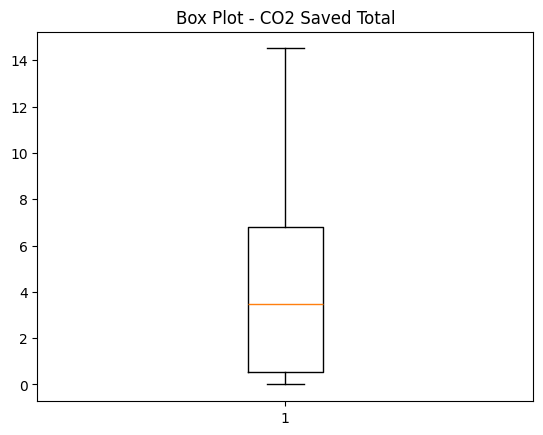

In [43]:
plt.boxplot(x=df_analysis['co2_saved_log'])
plt.title('Box Plot - CO2 Saved Total')
plt.show()

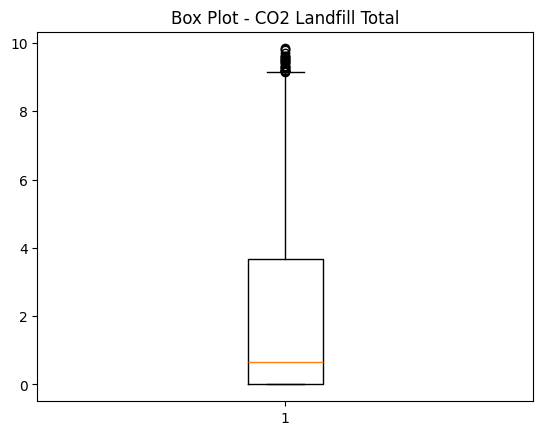

In [48]:

plt.boxplot(x=df_analysis['co2_landfill_log'])
plt.title('Box Plot - CO2 Landfill Total')
plt.show()

In [49]:
Q1 = df_analysis['co2_saved_total_kg'].quantile(0.25)
Q3 = df_analysis['co2_saved_total_kg'].quantile(0.75)
IQR = Q3 -Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 *IQR

df_analysis['co2_saved_clipped'] = df_analysis['co2_saved_total_kg'].clip(
    lower=lower,
    upper=upper
)

In [50]:
Q1 = df_analysis['co2_landfill_total_kg'].quantile(0.25)
Q3 = df_analysis['co2_landfill_total_kg'].quantile(0.75)
IQR = Q3 -Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 *IQR

df_analysis['co2_landfill_clipped'] = df_analysis['co2_landfill_total_kg'].clip(
    lower=lower,
    upper=upper
)

In [52]:
df_analysis['Gap'] = df_analysis['co2_saved_clipped'] - df_analysis['co2_landfill_clipped']
gap_country = df_analysis.groupby('country')['Gap'].sum().reset_index()
gap_country

,country,Gap
0,Australia,691555.95300
1,Brazil,659653.29750
2,Canada,745259.95900
3,China,693912.32850
4,Egypt,703375.69200
5,France,728334.74400
6,Germany,678298.20675
7,India,660002.71475
8,Indonesia,677945.98950
9,Japan,698798.42150


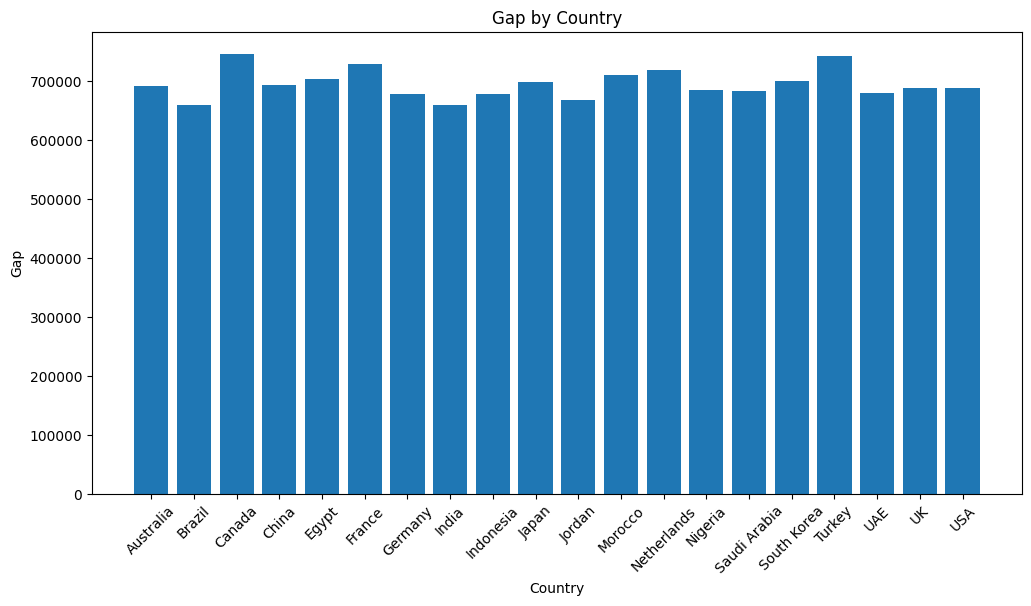

In [54]:
plt.figure(figsize=(12,6))
plt.bar(x=gap_country['country'], height=gap_country['Gap'])
plt.xlabel('Country')
plt.ylabel('Gap')
plt.title('Gap by Country')
plt.xticks(rotation=45)
plt.show()

wich regions have a high percentage of co2 saved

In [67]:
region_ber_co2 = df_analysis.groupby('region')['co2_saved_clipped'].sum().reset_index()
region_ber_co2

,region,co2_saved_clipped
0,Asia-Pacific,4.306022e+06
1,Europe,3.707797e+06
2,Latin America,6.898065e+05
3,MENA,3.594632e+06
4,N. America,1.495888e+06
5,Sub-Saharan Africa,7.152223e+05


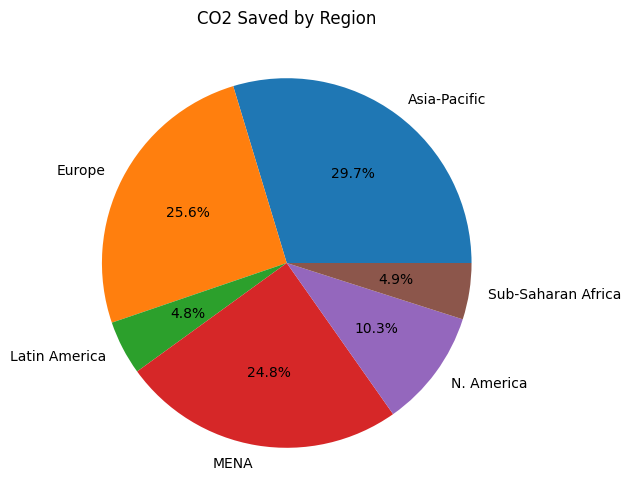

In [69]:
plt.figure(figsize=(12,6))
plt.pie(
    region_ber_co2['co2_saved_clipped'],
    labels=region_ber_co2['region'],
    autopct='%2.1f%%'
)

plt.title('CO2 Saved by Region')
plt.show()

In [77]:
df['region'].value_counts()

region
Asia-Pacific          7514
MENA                  6300
Europe                6275
N. America            2524
Sub-Saharan Africa    1223
Latin America         1164
Name: count, dtype: int64

In [ ]:
import folium
import pandas as pd
import branca.colormap as cm
from IPython.display import display
display(m)

# ---------------------------
# 2) إحداثيات لكل region
# (ممكن تعدلها حسب الداتا لو حابب)
# ---------------------------
region_coords = {
    "Asia-Pacific": [20, 100],
    "MENA": [24, 45],
    "Europe": [54, 15],
    "N. America": [54, -105],
    "Sub-Saharan Africa": [0, 20],
    "Latin America": [-10, -60]
}

# ---------------------------
# 3) ربط الإحداثيات بالداتا
# ---------------------------
region_ber_co2['lat'] = region_ber_co2['region'].map(lambda x: region_coords[x][0])
region_ber_co2['lon'] = region_ber_co2['region'].map(lambda x: region_coords[x][1])

# ---------------------------
# 4) إنشاء الخريطة
# ---------------------------
m = folium.Map(location=[20, 0], zoom_start=2)

# ---------------------------
# 5) Color Scale (احترافي 🔥)
# ---------------------------
colormap = cm.linear.YlOrRd_09.scale(
    region_ber_co2['co2_saved_clipped'].min(),
    region_ber_co2['co2_saved_clipped'].max()
)

# ---------------------------
# 6) إضافة نقاط على الخريطة
# ---------------------------
for _, row in region_ber_co2.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=10,
        popup=f"{row['region']}<br>CO2 Saved: {row['co2_saved_clipped']:.2f}",
        color=colormap(row['co2_saved_clipped']),
        fill=True,
        fill_color=colormap(row['co2_saved_clipped'])
    ).add_to(m)

# ---------------------------
# 7) إضافة الـ legend
# ---------------------------
colormap.add_to(m)

# ---------------------------
# 8) عرض الخريطة
# ---------------------------

m.save("map.html")

# Recycling Efficiency